## **Setup paths + load epistasis output**

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

# Project dirs (relative to BB-QTL_HT/5_epistasis/)
DATA_DIR   = Path("data")
OUT_DIR    = Path("output")
RESULTS_DIR = Path("results")
FIG_DIR     = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

epi_path = OUT_DIR / "epi_flu_qtl_1335.epi.qt"
print("Reading:", epi_path)

epi = pd.read_csv(epi_path, sep=r"\s+")
print("Epistasis shape:", epi.shape)
print("Columns:", list(epi.columns))

# Derived
epi["neglog10P"] = -np.log10(epi["P"].clip(lower=np.nextafter(0, 1)))
epi.head()

Reading: output/epi_flu_qtl_1335.epi.qt
Epistasis shape: (21325, 7)
Columns: ['CHR1', 'SNP1', 'CHR2', 'SNP2', 'BETA_INT', 'STAT', 'P']


,CHR1,SNP1,CHR2,SNP2,BETA_INT,STAT,P,neglog10P
0,5,snp10459,7,snp14392,-0.006083,28.8020,8.035000e-08,7.095014
1,5,snp10459,7,snp14393,-0.006106,29.0187,7.184000e-08,7.143634
2,5,snp10459,7,snp14394,-0.006078,28.7570,8.223000e-08,7.084970
3,5,snp10459,7,snp14395,-0.006168,29.6159,5.279000e-08,7.277448
4,5,snp10459,7,snp14396,-0.006168,29.6159,5.279000e-08,7.277448


## **Load SNP metadata + annotate SNP1/SNP2 with genes and positions**

In [3]:
snp = pd.read_csv(DATA_DIR / "snp_info_complete.tsv", sep="\t")

ann = snp[["SNP","Chromosome","Position (bp)","gene_name","gene_standard_name","feature_type"]].copy()
ann["SNP"] = ann["SNP"].astype(str)
ann["Chromosome"] = ann["Chromosome"].astype(str)

epi_annot = (
    epi
    .merge(ann.add_prefix("A_"), left_on="SNP1", right_on="A_SNP", how="left")
    .merge(ann.add_prefix("B_"), left_on="SNP2", right_on="B_SNP", how="left")
)

# Prefer standard names; fallback to ORF
epi_annot["geneA"] = epi_annot["A_gene_standard_name"].astype(str)
epi_annot["geneB"] = epi_annot["B_gene_standard_name"].astype(str)

epi_annot.loc[epi_annot["geneA"].isin(["", "nan", "None"]), "geneA"] = epi_annot["A_gene_name"].astype(str)
epi_annot.loc[epi_annot["geneB"].isin(["", "nan", "None"]), "geneB"] = epi_annot["B_gene_name"].astype(str)

epi_annot["same_gene"] = epi_annot["geneA"].eq(epi_annot["geneB"])

print("Annotated epistasis shape:", epi_annot.shape)
epi_annot[["CHR1","SNP1","geneA","CHR2","SNP2","geneB","BETA_INT","P"]].head()

Annotated epistasis shape: (21325, 23)


,CHR1,SNP1,geneA,CHR2,SNP2,geneB,BETA_INT,P
0,5,snp10459,NUP157,7,snp14392,KAP122,-0.006083,8.035000e-08
1,5,snp10459,NUP157,7,snp14393,KAP122,-0.006106,7.184000e-08
2,5,snp10459,NUP157,7,snp14394,KAP122,-0.006078,8.223000e-08
3,5,snp10459,NUP157,7,snp14395,KAP122,-0.006168,5.279000e-08
4,5,snp10459,NUP157,7,snp14396,KAP122,-0.006168,5.279000e-08


## **Add BH-FDR (within reported interactions)**

In [4]:
epi_annot = epi_annot.sort_values("P").reset_index(drop=True).copy()
m = epi_annot.shape[0]
p = epi_annot["P"].to_numpy(float)
rank = np.arange(1, m+1)

epi_annot["FDR_BH"] = np.minimum.accumulate((p * m / rank)[::-1])[::-1]
epi_annot["FDR_BH"] = epi_annot["FDR_BH"].clip(upper=1)

print("Hits at FDR < 0.05:", int((epi_annot["FDR_BH"] < 0.05).sum()))
print("Hits at FDR < 0.10:", int((epi_annot["FDR_BH"] < 0.10).sum()))
epi_annot.head()

Hits at FDR < 0.05: 21325
Hits at FDR < 0.10: 21325


,CHR1,SNP1,CHR2,SNP2,BETA_INT,STAT,P,neglog10P,A_SNP,A_Chromosome,...,B_SNP,B_Chromosome,B_Position (bp),B_gene_name,B_gene_standard_name,B_feature_type,geneA,geneB,same_gene,FDR_BH
0,7,snp14442,14,snp34732,0.033153,602.769,4.622000e-133,132.335170,snp14442,7,...,snp34732,14,467214,YNL085W,MKT1,genic,ERG4,MKT1,False,3.397073e-129
1,7,snp14442,14,snp34731,0.033142,602.588,5.060000e-133,132.295849,snp14442,7,...,snp34731,14,467023,YNL085W,MKT1,intergenic,ERG4,MKT1,False,3.397073e-129
2,7,snp14441,14,snp34732,0.033130,602.021,6.724000e-133,132.172372,snp14441,7,...,snp34732,14,467214,YNL085W,MKT1,genic,ERG4,MKT1,False,3.397073e-129
3,7,snp14441,14,snp34731,0.033119,601.840,7.362000e-133,132.133004,snp14441,7,...,snp34731,14,467023,YNL085W,MKT1,intergenic,ERG4,MKT1,False,3.397073e-129
4,7,snp14440,14,snp34732,0.033114,601.499,8.729000e-133,132.059036,snp14440,7,...,snp34732,14,467214,YNL085W,MKT1,genic,PDR1,MKT1,False,3.397073e-129


## **Add QTL interval IDs to SNPs (for within-QTL vs between-QTL)**

In [5]:
qtl = pd.read_csv(DATA_DIR / "Fluconazole_QTL_genes_20260122.csv")
qtl = qtl[["interval_id","chrom","start","end"]].drop_duplicates().copy()
qtl["chrom"] = qtl["chrom"].astype(str)

# Assign each SNP to the first matching QTL interval (ok if intervals don't overlap)
snp_pos = snp[["SNP","Chromosome","Position (bp)"]].copy()
snp_pos["Chromosome"] = snp_pos["Chromosome"].astype(str)

def assign_qtl_id(chrom, pos):
    hits = qtl[(qtl["chrom"] == chrom) & (qtl["start"] <= pos) & (qtl["end"] >= pos)]
    return hits["interval_id"].iloc[0] if len(hits) else np.nan

snp_pos["QTL_id"] = [assign_qtl_id(c, p) for c, p in zip(snp_pos["Chromosome"], snp_pos["Position (bp)"])]

snp_qtl = snp_pos[["SNP","QTL_id"]].copy()

epi_qtl = (
    epi_annot
    .merge(snp_qtl.add_prefix("A_"), left_on="SNP1", right_on="A_SNP", how="left")
    .merge(snp_qtl.add_prefix("B_"), left_on="SNP2", right_on="B_SNP", how="left")
)

epi_qtl["same_qtl"] = epi_qtl["A_QTL_id"].eq(epi_qtl["B_QTL_id"])

print("Within-QTL:", int(epi_qtl["same_qtl"].sum()))
print("Between-QTL:", int((~epi_qtl["same_qtl"]).sum()))
epi_qtl[["SNP1","A_QTL_id","SNP2","B_QTL_id","same_qtl","P"]].head()

Within-QTL: 0
Between-QTL: 21325


,SNP1,A_QTL_id,SNP2,B_QTL_id,same_qtl,P
0,snp14442,14442.0,snp34732,NaN,False,4.622000e-133
1,snp14442,14442.0,snp34731,34730.0,False,5.060000e-133
2,snp14441,14442.0,snp34732,NaN,False,6.724000e-133
3,snp14441,14442.0,snp34731,34730.0,False,7.362000e-133
4,snp14440,14442.0,snp34732,NaN,False,8.729000e-133


## **Generate figure**

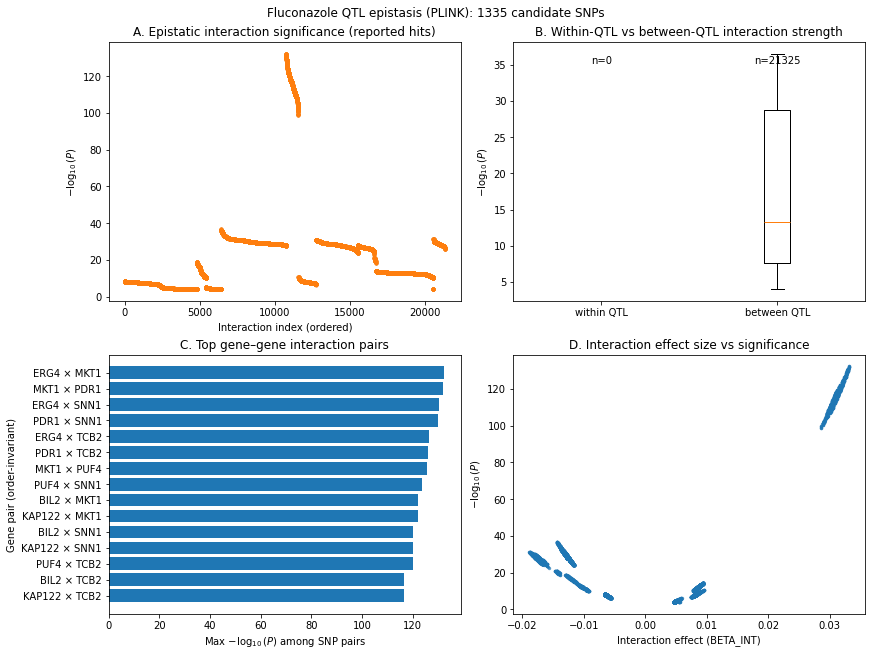

Saved:
 - results/figures/FigX_epistasis_fluconazole_1335snps.png
 - results/figures/FigX_epistasis_fluconazole_1335snps.pdf


In [6]:
import matplotlib.pyplot as plt

# Panel A ordering
dfA = epi_qtl.sort_values(["CHR1","CHR2","P"]).reset_index(drop=True)

# Panel B data
within = epi_qtl.loc[epi_qtl["same_qtl"], "neglog10P"].to_numpy()
between = epi_qtl.loc[~epi_qtl["same_qtl"], "neglog10P"].to_numpy()

# Panel C gene-pair summary
g1 = epi_qtl["geneA"].astype(str)
g2 = epi_qtl["geneB"].astype(str)
epi_qtl["gene_pair"] = np.where(g1 <= g2, g1 + " × " + g2, g2 + " × " + g1)

gp = (epi_qtl.groupby("gene_pair", as_index=False)
        .agg(minP=("P","min"),
             n_snp_pairs=("P","size"),
             max_neglog10P=("neglog10P","max"))
     ).sort_values(["minP","n_snp_pairs"], ascending=[True, False]).head(15)

# ---- Plot ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
(ax1, ax2), (ax3, ax4) = axes

# A
ax1.scatter(np.arange(dfA.shape[0]), dfA["neglog10P"], s=6, alpha=0.6)
sig = dfA["FDR_BH"] < 0.05
if sig.any():
    ax1.scatter(np.where(sig)[0], dfA.loc[sig, "neglog10P"], s=10, alpha=0.9)
ax1.set_title("A. Epistatic interaction significance (reported hits)")
ax1.set_xlabel("Interaction index (ordered)")
ax1.set_ylabel(r"$-\log_{10}(P)$")

# B
ax2.boxplot([within, between], labels=["within QTL", "between QTL"], showfliers=False)
ax2.set_title("B. Within-QTL vs between-QTL interaction strength")
ax2.set_ylabel(r"$-\log_{10}(P)$")
ylim = ax2.get_ylim()
ax2.text(1, ylim[1]*0.95, f"n={len(within)}", ha="center", va="top")
ax2.text(2, ylim[1]*0.95, f"n={len(between)}", ha="center", va="top")

# C
ax3.barh(gp["gene_pair"][::-1], gp["max_neglog10P"][::-1])
ax3.set_title("C. Top gene–gene interaction pairs")
ax3.set_xlabel(r"Max $-\log_{10}(P)$ among SNP pairs")
ax3.set_ylabel("Gene pair (order-invariant)")

# D
ax4.scatter(epi_qtl["BETA_INT"], epi_qtl["neglog10P"], s=6, alpha=0.6)
ax4.set_title("D. Interaction effect size vs significance")
ax4.set_xlabel("Interaction effect (BETA_INT)")
ax4.set_ylabel(r"$-\log_{10}(P)$")

fig.suptitle("Fluconazole QTL epistasis (PLINK): 1335 candidate SNPs")

out_png = FIG_DIR / "FigX_epistasis_fluconazole_1335snps.png"
out_pdf = FIG_DIR / "FigX_epistasis_fluconazole_1335snps.pdf"
fig.savefig(out_png, dpi=300)
fig.savefig(out_pdf)
plt.show()

print("Saved:")
print(" -", out_png)
print(" -", out_pdf)